# Análisis Exploratorio de Datos de Airbnb en Ciudad de México

### Exploración de precios, alojamientos y distribución geográfica utilizando Polars

### Luis Enrique Hernández Torres A01662166

**Objetivo:** Analizar los datos de alojamientos de Airbnb en la Ciudad de México para identificar patrones en precios, tipos de alojamiento, alcaldías con mayor oferta y principales anfitriones, complementando el análisis con visualizaciones estadísticas y geográficas.

In [3]:
#!pip install polars
import polars as pl

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt 



In [5]:
#Configuración del estilo visual 
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6) 
# Deshabilitar el limite de 5000 filas de Altair
alt.data_transformers.enable('default', max_rows=None)
print("Librerías importadas")

Librerías importadas


In [6]:
url= "https://data.insideairbnb.com/mexico/df/mexico-city/2026-06-15/data/listings.csv.gz"
print("Cargando datos desde:", url)

Cargando datos desde: https://data.insideairbnb.com/mexico/df/mexico-city/2026-06-15/data/listings.csv.gz


In [8]:
try:
    # Cargar los datos en un DataFrame de Polars
    df = pl.read_csv(url)
    print("Datos cargados exitosamente.")
except Exception as e:
    print("Error al cargar los datos:", e)

Datos cargados exitosamente.


In [9]:
# Limpieza inicial
if not df.is_empty():
    df = (
        df.with_columns(
            pl.col("price")
            .cast(pl.Utf8)
            .str.replace_all(r"\$", "")
            .str.replace_all(",", "")
            .cast(pl.Float32, strict=False)
            .alias("price")
        )
        .drop_nulls(subset=["price"])
        .filter(pl.col("price") > 0)
    )

    print("Limpieza inicial realizada")
    display(df.head(5))

Limpieza inicial realizada


id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,…,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
i64,str,i64,str,str,str,str,str,str,i64,str,i64,str,str,str,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,str,str,f64,…,i64,i64,i64,i64,i64,f64,f64,str,str,i64,i64,i64,i64,str,i64,i64,i64,i64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,str,str,i64,i64,i64,i64,f64
1698274831948209016,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-16""","""city scrape""","""Roma Residence | Luxury Suite …","""Discover Condesa Residence Lux…",null,"""https://a0.muscache.com/pictur…",471105419,"""https://www.airbnb.com/users/s…",1470124798213804330,"""https://www.airbnb.com/users/p…","""Manuel""",null,3,10,3,10,"""Mexico City, Mexico""","""Para mí será un placer ser tu …",null,null,null,"""t""",null,"""https://a0.muscache.com/im/pic…",null,42,null,"""None""","""t""","""t""",null,"""Cuauhtémoc""",null,19.406572,…,365,1,2,365,365,1.0,365.0,null,"""t""",30,60,90,365,"""2026-06-16""",0,0,0,199,0,0,0,null,null,null,null,null,null,null,null,null,null,null,42,42,0,0,null
1120444645818769896,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-17""","""city scrape""","""Grande y bonita habitación con…","""Disconnect from your worries i…",null,"""https://a0.muscache.com/pictur…",548898239,"""https://www.airbnb.com/users/s…",1470455484134025896,"""https://www.airbnb.com/users/p…","""Catu""",null,2,6,2,2,"""Mexico City, Mexico""",null,null,null,null,"""f""",null,"""https://a0.muscache.com/im/pic…",null,1,null,"""None""","""t""","""t""",null,"""Benito Juárez""",null,19.394448,…,365,1,1,365,365,1.0,365.0,null,"""t""",17,47,77,257,"""2026-06-17""",0,0,0,185,0,0,0,null,null,null,null,null,null,null,null,null,null,null,1,1,0,0,null
1414477907775396874,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-17""","""city scrape""","""Ven a sentirte como en casa.""","""Relax with the whole family at…",null,"""https://a0.muscache.com/pictur…",49281983,"""https://www.airbnb.com/users/s…",1465750516819044639,"""https://www.airbnb.com/users/p…","""Mireya""",null,10,7,10,6,"""Mexico City, Mexico""","""Persona amigable, atenta, gust…",null,null,null,"""f""",null,"""https://a0.muscache.com/im/pic…",null,2,null,"""None""","""t""","""t""",null,"""Coyoacán""",null,19.339362,…,365,1,1,365,365,1.0,365.0,null,"""t""",0,0,0,158,"""2026-06-17""",0,0,0,0,0,0,0,null,null,null,null,null,null,null,null,null,null,null,2,0,2,0,null
1298027147444763745,"""https://www.airbnb.com/rooms/1…",20260615212254,"""2026-06-17""","""city scrape""","""Habitación pequeña 16""","""You'll be close to everything …",null,"""https://a0.m

In [10]:
# Análisis básico 
print("1.1 ¿Cuál es el precio promedio por noche?")
avg_price = df.select(pl.col("price").mean()).item()
print(f"El precio promedio por noche es: ${avg_price:.2f}")
print("================================================")
print("1.2 ¿Cuáles son los tipos de alojamiento?")
room_types = df.group_by("room_type").agg(pl.len().alias("count")).sort("count", descending=True)
print("================================================")
print("Tipos de alojamiento y sus conteos:" )
display(room_types)
print("================================================")
print("1.3 Top 10 alcaldias con mas alojamientos")
top_alcaldias = (
    df.group_by("neighbourhood_cleansed")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(10)
)
print("Top 10 alcaldias con más alojamientos:")
display(top_alcaldias)
print("1.4 Quienes son los anfitriones con más alojamientos")
top_hosts = (
    df.group_by("host_name")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(10)
)
print("Top 10 anfitriones con más alojamientos:")
display(top_hosts)

1.1 ¿Cuál es el precio promedio por noche?
El precio promedio por noche es: $2913.69
1.2 ¿Cuáles son los tipos de alojamiento?
Tipos de alojamiento y sus conteos:


room_type,count
str,u32
"""Entire home/apt""",19856
"""Private room""",9407
"""Shared room""",291
"""Hotel room""",83


1.3 Top 10 alcaldias con mas alojamientos
Top 10 alcaldias con más alojamientos:


neighbourhood_cleansed,count
str,u32
"""Cuauhtémoc""",13683
"""Miguel Hidalgo""",4540
"""Benito Juárez""",3373
"""Coyoacán""",2334
"""Tlalpan""",1064
"""Venustiano Carranza""",1022
"""Álvaro Obregón""",974
"""Iztacalco""",569
"""Gustavo A. Madero""",531


1.4 Quienes son los anfitriones con más alojamientos
Top 10 anfitriones con más alojamientos:


host_name,count
str,u32
"""Alejandro""",312
"""Juan""",291
"""Daniel""",251
"""Jorge""",235
"""Alejandra""",225
"""Carlos""",222
"""Capitalia""",221
"""Clau""",208
"""Diego""",204


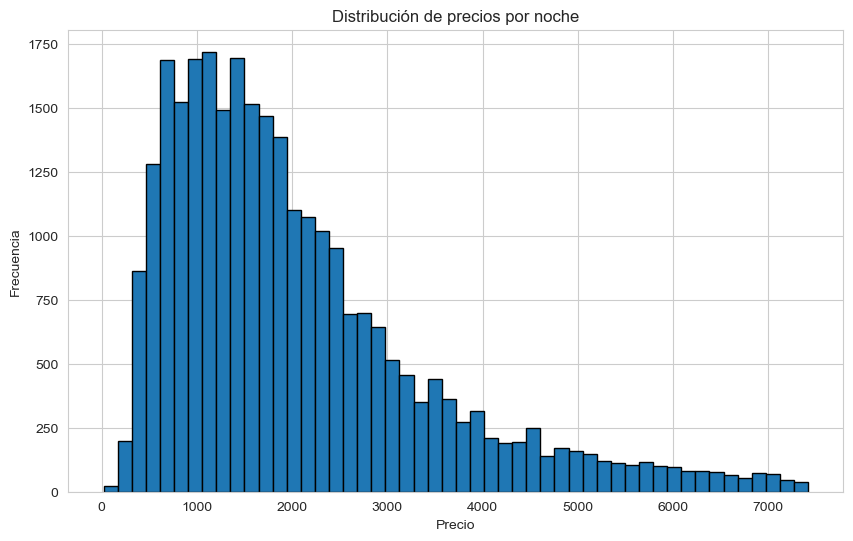

In [15]:
# Visualización de la distribución de precios

# Calcular el percentil 95 de la columna price
price_q95 = df.select(
    pl.col("price").quantile(0.95)
).item()

# Filtrar los precios por debajo del percentil 95
# y convertir el resultado a pandas
price_to_plot_df = (
    df
    .filter(pl.col("price") < price_q95)
    .select("price")
    .to_pandas()
)

# Graficar la distribución de precios
plt.figure(figsize=(10, 6))

plt.hist(
    price_to_plot_df["price"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribución de precios por noche")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

In [17]:
#Graficar el top de alcaldias
top_alcaldias_df = top_alcaldias.to_pandas()
fig_hoods = px.bar(
    top_alcaldias_df,
    y="neighbourhood_cleansed",
    x="count",
    orientation="h",
    title="Top 10 alcaldias con más alojamientos",
    labels={"neighbourhood_cleansed": "Alcaldia", "count": "Número de alojamientos"},
    color="count",
    color_continuous_scale="Viridis"
)
fig_hoods.show()

In [18]:
# === Gráfico 5: Mapa Geográfico de Precios ===

df_sample_for_plot = (
    df.filter(
        pl.col("price") < df.select(pl.col("price").quantile(0.95)).item()
    )
    .sample(n=5000, seed=42)
    .to_pandas()
)

# Versión con Plotly Express (Mapa Interactivo)
# Nota: Plotly usa Mapbox para los mapas.

fig_map = px.scatter_mapbox(
    df_sample_for_plot,
    lat="latitude",
    lon="longitude",
    color="price",
    size="price",
    color_continuous_scale=px.colors.sequential.Viridis_r,
    size_max=15,
    zoom=10,
    mapbox_style="carto-positron",
    hover_name="name",
    hover_data={
        "neighbourhood_cleansed": True,
        "price": ":$.2f"
    }
)

fig_map.update_layout(
    title="Mapa Interactivo de Precios de Airbnb en CDMX",
    legend_title_text="Precio (MXN)"
)

fig_map.show()